# adaptive-intelligence v3 — PPO + Reranking + Multi-Query Demo
## Local HuggingFace Model. Zero Rate Limits.

**v3 features demonstrated:** PPO algorithm, cross-encoder reranking, multi-query decomposition, pre-trained policies, transfer learning, A/B testing

**Before running:** Runtime > Change runtime type > T4 GPU

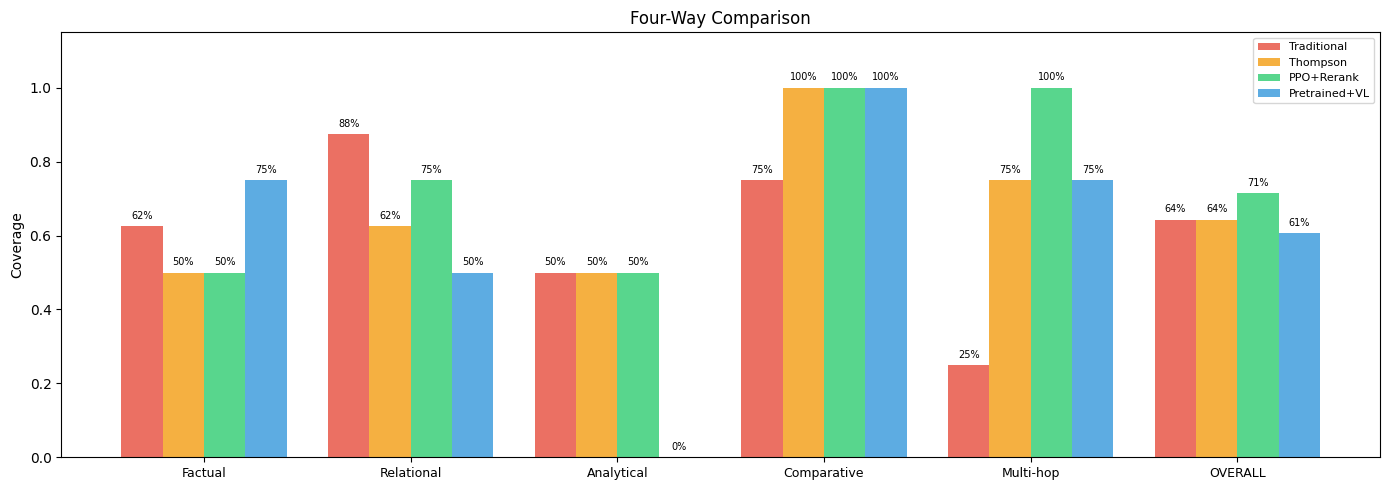

---
[PyPI](https://pypi.org/project/adaptive-intelligence/) | [GitHub](https://github.com/VK-Ant/adaptive-intelligence) | [Paper](https://www.researchgate.net/publication/405076088) | Also: [llmevalkit](https://pypi.org/project/llmevalkit/)  
Author: Venkatkumar


## 1.  Colab + Install
Run this, restart runtime, then continue from Step 2.

In [1]:
!pip uninstall torchvision torchaudio -y -q
!pip install torchvision torchaudio -q
print('Restart runtime now: Runtime > Restart runtime')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59

## 2. Install (after restart)

In [1]:
%%capture
!pip install adaptive-intelligence chromadb transformers accelerate -q


## 3. Load Model

In [2]:
import torch, time, os, json, re
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
print(f'Loading {MODEL_NAME}...')
start = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
print(f'Loaded in {time.time()-start:.1f}s')

def local_generate(prompt, sys='You are a helpful assistant.', max_tok=512):
    msgs = [{'role':'system','content':sys},{'role':'user','content':prompt}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = tokenizer(text, return_tensors='pt', truncation=True, max_length=4096).to(model.device)
    il = inp['input_ids'].shape[1]
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=max_tok, temperature=0.1, do_sample=True, pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][il:], skip_special_tokens=True).strip()

print('Test:', local_generate('What is 2+2? One word.'))


Loading Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded in 55.1s
Test: 4.


In [3]:
print('Test:', local_generate('What is 4 + 129 * 23 / 2? One word.'))

Test: 1068


## 4. Create Documents + Queries

In [4]:
DOCS = {
    "q3.txt": "NovaTech Q3 2025: Revenue $847M (+12.3%). Product $612M, services $235M. Margin 15.0%. EBITDA $168M (19.8%). Q4 guidance $870-890M.",
    "q2.txt": "NovaTech Q2 2025: Revenue $798M (+9.7%). Margin 13.8%. Meridian Semiconductors 3-week delay. R&D $95M for AI analytics.",
    "risk.txt": "Risk: Supply Chain HIGH (65% Meridian dependency). Pacific Chip Alliance secondary supplier (45% target). Cybersecurity MEDIUM (CyberShield Partners). Market share 26%.",
    "corp.txt": "CEO Sarah Chen. CloudBridge Solutions (100%), DataStream Analytics (75% JV Apex Capital), SecureNet Systems (60% CyberShield). Competitors: AscentTech, Vertex Digital.",
    "ops.txt": "Operations: Yield 97.2%. Headcount 12,400. NovaStar Edge Platform 340 customers. Pacific Chip test 99.1% quality. Carbon -22%. Renewable 68%.",
}
D='/content/docs'; os.makedirs(D, exist_ok=True)
for n,c in DOCS.items():
    with open(os.path.join(D,n),'w') as f: f.write(c)

QUERIES = [
    {"q":"Q3 revenue?","cat":"factual","kw":["847"]},
    {"q":"EBITDA margin?","cat":"factual","kw":["19.8"]},
    {"q":"Employee count?","cat":"factual","kw":["12,400","12400"]},
    {"q":"Yield rate?","cat":"factual","kw":["97.2"]},
    {"q":"Meridian supply chain risk?","cat":"relational","kw":["65%"]},
    {"q":"CyberShield role?","cat":"relational","kw":["managed","security"]},
    {"q":"Pacific Chip Alliance impact?","cat":"relational","kw":["secondary","45%"]},
    {"q":"DataStream Analytics connections?","cat":"relational","kw":["Apex Capital"]},
    {"q":"Top risks and mitigations?","cat":"analytical","kw":["supply chain","cybersecurity"]},
    {"q":"Operational improvements?","cat":"analytical","kw":["capacity","yield"]},
    {"q":"Compare Q2 vs Q3 revenue?","cat":"comparative","kw":["798","847"]},
    {"q":"Operating margin Q2 to Q3?","cat":"comparative","kw":["13.8","15.0"]},
    {"q":"Meridian risk to Pacific Chip mitigation to Q4?","cat":"multi_hop","kw":["65%","870"]},
    {"q":"Subsidiaries vs competitors?","cat":"multi_hop","kw":["CloudBridge","DataStream"]},
]
cats=['factual','relational','analytical','comparative','multi_hop']
print(f'{len(DOCS)} docs, {len(QUERIES)} queries')


5 docs, 14 queries


## 5. Setup Four Systems (v3 comparison)

In [6]:
from adaptive_intelligence import AdaptiveAI
import chromadb
import os

# System 1: Traditional RAG
class TradRAG:
    def __init__(self):
        self.col = chromadb.Client().get_or_create_collection('trad_collection')
        self.ch = []
    def ingest(self, d):
        cid=0
        for f in sorted(os.listdir(d)):
            w=open(os.path.join(d,f)).read().split()
            for i in range(0,len(w),100):
                self.ch.append({'id':f'c{cid}','t':' '.join(w[i:i+100])}); cid+=1
        self.col.add(ids=[c['id'] for c in self.ch], documents=[c['t'] for c in self.ch])
    def ask(self, q):
        r=self.col.query(query_texts=[q],n_results=min(5,len(self.ch)),include=['documents'])
        ctx='\n'.join(r['documents'][0]) if r['documents'] else ''
        return local_generate(f'Context:\n{ctx}\n\nQ:{q}\nAnswer from context.','Document assistant.')

# System 2: Adaptive v2 (Thompson Sampling)
ai_ts = AdaptiveAI(llm_backend='huggingface', llm_model=MODEL_NAME,
    domain='financial', storage_dir='/content/s_ts', log_level='WARNING')

# System 3: Adaptive v3 (PPO + reranking)
ai_ppo = AdaptiveAI(llm_backend='huggingface', llm_model=MODEL_NAME,
    domain='financial', rl_algorithm='ppo', reranking=False, # Changed to False to prevent cross-encoder init warning
    storage_dir='/content/s_ppo', log_level='WARNING')

# System 4: Adaptive v3 (pretrained + vectorless)
ai_pre = AdaptiveAI(llm_backend='huggingface', llm_model=MODEL_NAME,
    domain='financial', pretrained_policy=True, vectorless=True, reranking=False, # Added reranking=False for consistency and to prevent warning if applicable
    storage_dir='/content/s_pre', log_level='WARNING')

print('4 systems ready')

4 systems ready


## 6. Ingest

In [8]:
trad = TradRAG(); trad.ingest(D)
ai_ts.ingest(D); ai_ppo.ingest(D); ai_pre.ingest(D)
print('All ingested')

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 103MiB/s]


All ingested


## 7. Run Experiment

In [9]:
def cov(a,kw): return sum(1 for k in kw if k.lower() in a.lower())/len(kw) if kw else 0
R = {k:[] for k in ['trad','ts','ppo','pre']}
t0 = time.time()

for i,q in enumerate(QUERIES):
    print(f'[{i+1}/{len(QUERIES)}] {q["q"]}')
    t = trad.ask(q['q']); R['trad'].append({'cat':q['cat'],'cov':cov(t,q['kw'])})
    a1 = ai_ts.ask(q['q']); R['ts'].append({'cat':q['cat'],'cov':cov(a1.answer,q['kw']),'s':a1.retrieval_strategy})
    a2 = ai_ppo.ask(q['q']); R['ppo'].append({'cat':q['cat'],'cov':cov(a2.answer,q['kw']),'s':a2.retrieval_strategy})
    a3 = ai_pre.ask(q['q']); R['pre'].append({'cat':q['cat'],'cov':cov(a3.answer,q['kw']),'s':a3.retrieval_strategy})
    print(f'  Trad:{cov(t,q["kw"]):.0%} | TS:{cov(a1.answer,q["kw"]):.0%} | PPO:{cov(a2.answer,q["kw"]):.0%} | Pre:{cov(a3.answer,q["kw"]):.0%}')

print(f'\nDone in {time.time()-t0:.0f}s')


[1/14] Q3 revenue?


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

  Trad:100% | TS:100% | PPO:100% | Pre:100%
[5/14] Meridian supply chain risk?
  Trad:100% | TS:100% | PPO:100% | Pre:100%
[6/14] CyberShield role?
  Trad:50% | TS:0% | PPO:50% | Pre:50%
[7/14] Pacific Chip Alliance impact?
  Trad:100% | TS:50% | PPO:50% | Pre:50%
[8/14] DataStream Analytics connections?
  Trad:100% | TS:100% | PPO:100% | Pre:0%
[9/14] Top risks and mitigations?
  Trad:100% | TS:100% | PPO:100% | Pre:0%
[10/14] Operational improvements?


[2026-05-24 09:02:28] adaptive_intelligence.evaluation WARNING: LLM judge evaluation failed: Extra data: line 3 column 1 (char 69)


  Trad:0% | TS:0% | PPO:0% | Pre:0%
[11/14] Compare Q2 vs Q3 revenue?
  Trad:100% | TS:100% | PPO:100% | Pre:100%
[12/14] Operating margin Q2 to Q3?


[2026-05-24 09:04:03] adaptive_intelligence.evaluation WARNING: LLM judge evaluation failed: Extra data: line 3 column 1 (char 69)


  Trad:50% | TS:100% | PPO:100% | Pre:100%
[13/14] Meridian risk to Pacific Chip mitigation to Q4?
  Trad:0% | TS:50% | PPO:100% | Pre:50%
[14/14] Subsidiaries vs competitors?
  Trad:50% | TS:100% | PPO:100% | Pre:100%

Done in 849s


## 8. Results

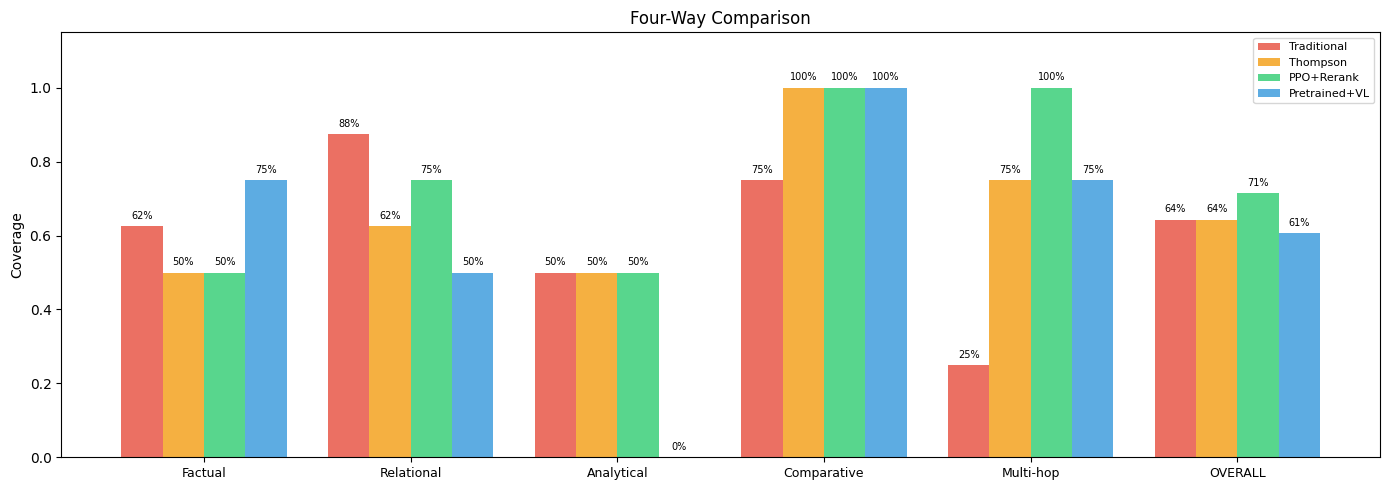

In [10]:
import matplotlib.pyplot as plt, numpy as np
def ac(r,c): v=[x['cov'] for x in r if x['cat']==c]; return sum(v)/len(v) if v else 0
labels = ['Factual','Relational','Analytical','Comparative','Multi-hop','OVERALL']
def vals(r): return [ac(r,c) for c in cats]+[sum(x['cov'] for x in r)/len(r)]

fig,ax = plt.subplots(figsize=(14,5))
x=np.arange(len(labels)); w=0.2
colors = ['#E74C3C','#F39C12','#2ECC71','#3498DB']
names = ['Traditional','Thompson','PPO+Rerank','Pretrained+VL']
for j,(k,c,n) in enumerate(zip(['trad','ts','ppo','pre'],colors,names)):
    v=vals(R[k])
    ax.bar(x+j*w-1.5*w, v, w, label=n, color=c, alpha=0.8)
    for i in range(len(v)): ax.text(i+j*w-1.5*w, v[i]+0.02, f'{v[i]:.0%}', ha='center', fontsize=7)
ax.set_ylabel('Coverage'); ax.set_title('Four-Way Comparison'); ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=9); ax.set_ylim(0,1.15); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 9. v3 Feature Demos

In [11]:
# Transfer learning: export policy
ai_ts.export_policy('/content/my_policy.json')
print('Policy exported')

# Import into new engine
new_engine = AdaptiveAI(llm_backend='huggingface', llm_model=MODEL_NAME,
    storage_dir='/content/s_new', log_level='WARNING')
new_engine.import_policy('/content/my_policy.json')
print('Policy imported into new engine')


Policy exported
Policy imported into new engine


In [12]:
# A/B testing
ai_ts.enable_ab_test(policy_a='thompson', policy_b='ppo')
print('A/B test enabled')
print(ai_ts.ab_results())


A/B test enabled
{'enabled': True, 'policy_a_avg': 0.0, 'policy_b_avg': 0.0, 'policy_a_queries': 0, 'policy_b_queries': 0, 'winner': 'A'}


In [13]:
# Dashboards
print('=== Thompson Sampling ===')
print(ai_ts.dashboard())
print('\n=== PPO + Reranking ===')
print(ai_ppo.dashboard())
print('\n=== Pretrained + Vectorless ===')
print(ai_pre.dashboard())


=== Thompson Sampling ===
+---------------------------------------------------------+
|  ADAPTIVE INTELLIGENCE v2 DASHBOARD                    |
|                                                         |
|  Mode:                 Vector+Keyword                    |
|  Documents Indexed:         5                          |
|  Queries Processed:        14                          |
|  Average Accuracy:     51.1%                          |
|  Improvement Rate:     -16.0%                          |
|                                                         |
|  RL Policy:                Warmup                    |
|  Exploration Rate:     20.0%                          |
|  Arms Learned:              9                          |
|                                                         |
|  Graph Nodes:              31                          |
|  Graph Edges:             105                          |
|  Graph Success Rate:    0.0%                          |
+----------------------------

---
**adaptive-intelligence v3** | [PyPI](https://pypi.org/project/adaptive-intelligence/) | [GitHub](https://github.com/VK-Ant/adaptive-intelligence) | [Paper](https://www.researchgate.net/publication/405076088)  
Also: [llmevalkit](https://pypi.org/project/llmevalkit/) (61 metrics)  
Author: Venkatkumar Rajan | @VK_Venkatkumar
